In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [70]:
data = pd.read_csv('../data/data1.csv')

In [71]:
plt.figure(figsize=(12,6))

for i, x in enumerate(['x1', 'x2']):
    plt.subplot(1, 2, i+1)
    plt.scatter(data[x], data['y'], color='blue', label='Data Points')
    plt.xlabel(x)
    plt.title(f'Scatter Plot of y vs {x}')

plt.tight_layout()
# plt.show()
plt.close()

Prosty rysnek y(x1) i y(x2) sugerują, że istnieje jakaś liniowa zależność, z tym że w drugim przypadku wariancja raczej większa

In [72]:
plt.figure(figsize=(12,6))

a = {'x1': 1.1, 'x2': -1.0}
b = {'x1': -150, 'x2': 5.0}

for i, x in enumerate(['x1', 'x2']):
    plt.subplot(1, 2, i+1)
    plt.scatter(data[x], data['y'], color='blue', label='Data Points')
    plt.xlabel(x)
    plt.title(f'Scatter Plot of y vs {x}')

    x_linia = np.array([data[x].min(), data[x].max()])
    y_linia = a[x] * x_linia + b[x]

    plt.plot(x_linia, y_linia, color='red', label=f'Linia: y = {a[x]}*x + {b[x]}')

plt.tight_layout()
# plt.show()
plt.close()

Tutaj przykładowej naniesienie prostych na dane.

Teraz trzeba przygotować dane do modelowania. Regresja liniowa zdaje się być odpowiednia.

In [86]:
from sklearn.preprocessing import StandardScaler

def preprocess_data(X_train, y_train, scale=True):

    percent = 0.05 # tyle procent outlierów usuwamy

    n_remove = int(len(X_train) * percent)
    
    indices_sorted = np.argsort(np.abs(y_train))[::-1]

    outlier_indices = indices_sorted[:n_remove]

    mask = np.ones(len(y_train), dtype=bool)
    mask[outlier_indices] = False

    X_train_clean = X_train[mask]
    y_train_clean = y_train[mask]

    if scale:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_clean)
        return X_train_scaled, y_train_clean, scaler
    return X_train_clean, y_train_clean, None

In [74]:
X_scaled, y_scaled, scaler = preprocess_data(data[['x1', 'x2']], data['y'])

In [75]:
print(f"Średnia (x1, x2): {scaler.mean_}")
print(f"Odchylenie standardowe (x1, x2): {scaler.scale_}")

Średnia (x1, x2): [ 11.10058156 188.86317131]
Odchylenie standardowe (x1, x2): [225.27274739 112.39883486]


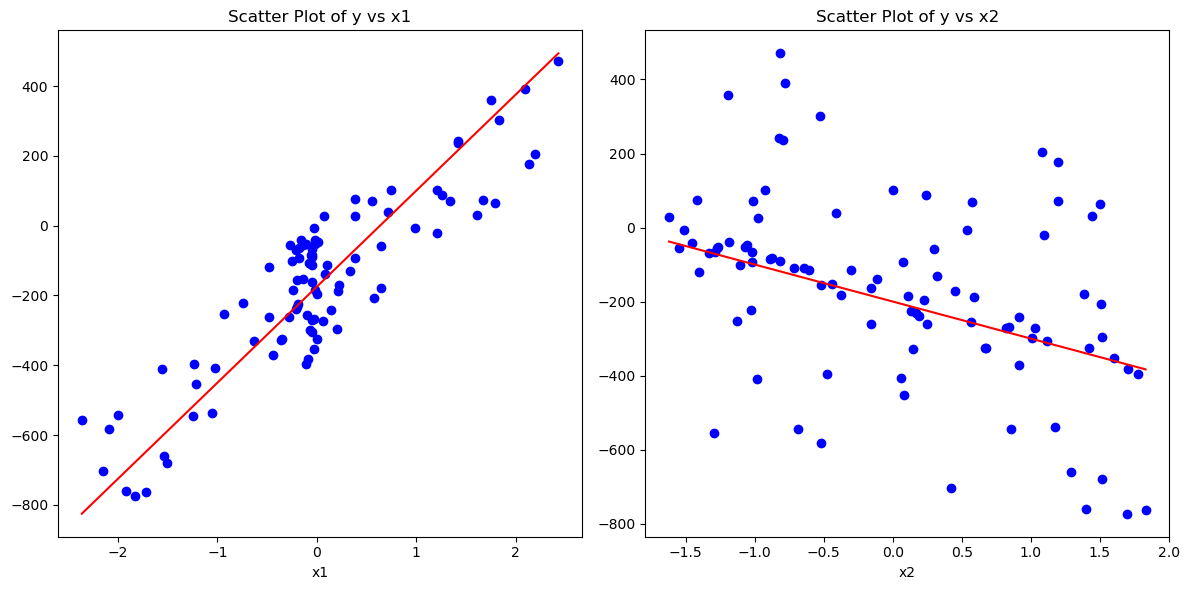

In [76]:
plt.figure(figsize=(12,6))

a = {'x1': 275, 'x2': -100.0}
b = {'x1': -175, 'x2': -200.0}

for i, x in enumerate(['x1', 'x2']):
    plt.subplot(1, 2, i+1)
    plt.scatter(X_scaled[:, i], y_scaled, color='blue', label='Data Points')
    plt.xlabel(x)
    plt.title(f'Scatter Plot of y vs {x}')

    x_linia = np.array([X_scaled[:, i].min(), X_scaled[:, i].max()])
    y_linia = a[x] * x_linia + b[x]

    plt.plot(x_linia, y_linia, color='red', label=f'Linia: y = {a[x]}*x + {b[x]}')

plt.tight_layout()
plt.show()
plt.close()

TUTAJ ZACZYNA SIE PRAWDZIWE 2 ZADANIE (WCZEŚNIEJSZY KOD JEST Z ZADANIA 1)

In [88]:
from sklearn.model_selection import train_test_split

data = pd.read_csv('../data/data1.csv')

X_train, X_test, y_train, y_test = train_test_split(data[['x1', 'x2']], data['y'], test_size=0.2, random_state=42)

In [98]:
X_train_scaled, y_train_scaled, scaler = preprocess_data(X_train, y_train, scale=True)
X_train_not_scaled, y_train_not_scaled, _ = preprocess_data(X_train, y_train, scale=False)

X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}, y_train shape: {y_train_scaled.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}, y_train shape: {y_train_scaled.shape}")

X_TRAIN_NO_PREPROCESS = X_train
y_TRAIN_NO_PREPROCESS = y_train

print(f"X_TRAIN_NO_PREPROCESS shape: {X_TRAIN_NO_PREPROCESS.shape}, y_TRAIN_NO_PREPROCESS shape: {y_TRAIN_NO_PREPROCESS.shape}")

X_train_scaled shape: (76, 2), y_train shape: (76,)
X_train_scaled shape: (76, 2), y_train shape: (76,)
X_TRAIN_NO_PREPROCESS shape: (80, 2), y_TRAIN_NO_PREPROCESS shape: (80,)


BASELINE MODEL

wcześniej sobie wybrałem współczynniki, które są na oko dobre

a = {'x1': 275, 'x2': -100.0}
b = {'x1': -175, 'x2': -200.0}

In [92]:
class BaselineModel: # definiuje prosty model bazowy, który jest po prosty y(x1, x2) = y(x1) = a1*x1 + b1
    def __init__(self, a, b):
        self.coef_ = np.array([a, 0])  # Współczynnik dla x2 jest zerowy
        self.intercept_ = b

    def fit(self, X, y=None):
        # Model bazowy nie wymaga dopasowania do danych
        return self

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            x1_column = X.iloc[:, 0]
        else:
            x1_column = X[:, 0]

        return self.coef_[0] * x1_column + self.intercept_
    
    def score(self, X, y):
        return 0.0  # Model bazowy zawsze zwraca 0 jako R²

No takie słabe ty wyniki, ale jak na zero trenowania też nie jest tak źle.

In [93]:
from sklearn.linear_model import LinearRegression
import sklearn.metrics as skm

model_lr_raw_data = LinearRegression()
model_lr_scaled_data = LinearRegression()

In [94]:
def model_train_eval(model, X_, y_, X_test_, y_test_, variant):
    model.fit(X_, y_)

    print(f"Coefficients: {model.coef_}, Intercept: {model.intercept_}")

    y_pred = model.predict(X_test_)
    rsc = model.score(X_test_, y_test_)
    mse = skm.mean_squared_error(y_test_, y_pred)
    mape = skm.mean_absolute_percentage_error(y_test, y_pred)
    mae = skm.mean_absolute_error(y_test, y_pred)

    return dict(variant=variant, MSE=mse, MAE=mae, MAPE=mape, Rsq=rsc, Coefficients=model.coef_, Intercept=model.intercept_)

In [95]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")


X_train shape: (80, 2), y_train shape: (80,)


In [99]:
all_results = []


all_results.append(model_train_eval(BaselineModel(a=275, b=-175), X_train, y_train, X_test, y_test, "baseline"))
all_results.append(model_train_eval(LinearRegression(fit_intercept=True), X_train_not_scaled, y_train_not_scaled, X_test, y_test, "raw"))
all_results.append(model_train_eval(LinearRegression(fit_intercept=True), X_train_scaled, y_train_scaled, X_test_scaled, y_test, "scaled"))
all_results.append(model_train_eval(LinearRegression(fit_intercept=True), X_TRAIN_NO_PREPROCESS, y_TRAIN_NO_PREPROCESS, X_test, y_test, "no_preprocess"))

results = pd.DataFrame(all_results)
results

Coefficients: [275   0], Intercept: -175
Coefficients: [ 1.00041559 -0.99883538], Intercept: 7.842770724201415
Coefficients: [ 239.08254138 -112.87087315], Intercept: -183.8054304469737
Coefficients: [ 0.86602687 -0.93133305], Intercept: 10.1541579400631


,variant,MSE,MAE,MAPE,Rsq,Coefficients,Intercept
0,baseline,3.125663e+09,33223.684175,179.950368,0.000000,"[275, 0]",-175.000000
1,raw,7.189219e-01,0.749805,0.006845,0.999989,"[1.0004155892533793, -0.998835379381481]",7.842771
2,scaled,7.189219e-01,0.749805,0.006845,0.999989,"[239.08254137766525, -112.8708731500884]",-183.805430
3,no_preprocess,1.043044e+03,26.221601,0.119939,0.984534,"[0.8660268723309907, -0.9313330466626194]",10.154158


Dopasowanie modelu jest tym lepsze, im wartość R² jest bliższa jedności.